# **Project : Product Return Prediction**

## Introduction
In this project, we focus on understanding the reasons behind product returns and predict whether a product will be returned. Our primary goal is to provide actionable insights to retailers rather than achieving the maximum model accuracy. By identifying patterns and factors that leads to returns, we aim to help businesses to reduce return rates and associated costs.

## Problem Statement
To Predict the likelihood of a product being returned based on various features such as product category, price and customer demographics. The goal of this project is to provide insights into the factors that contribute to product returns, enabling reatilers to make informed decisions and improve their return policies and customer experience.

## Business Problem
In the retail industry, product returns are a significant challenge, impacting profitablity and customer satisfaction. Understanding the reasons behind returns can help retailers improve their products, services and customer experience.     

## Mapping the Real-World Problem to a Machine Learning Problem
**It is a machine learning binary classification problem where we predict whether a order will be returned or not. By analyzing various order features, its aim to help businesses reduce return rates and improve customer satisfaction.**

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable

### Dispaly settings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')


### Data Ingestion and Exploration

In [3]:
path = Path.cwd()
paths = path.parent.joinpath('data','raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)

['.gitkeep', 'Global Superstore.xls']


In [4]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()

dict_keys(['Orders', 'Returns', 'People'])

In [5]:
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1)
,return_df.tail(1)
,people_df.tail(1))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [6]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)

'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [7]:
# remove whitespaces from column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip()

In [8]:
# Lets lower case all column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.lower()


In [9]:
# lets check the data types of the columns
order_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row id          51290 non-null  int64         
 1   order id        51290 non-null  object        
 2   order date      51290 non-null  datetime64[ns]
 3   ship date       51290 non-null  datetime64[ns]
 4   ship mode       51290 non-null  object        
 5   customer id     51290 non-null  object        
 6   customer name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product id      51290 non-null  object        
 15  ca

In [10]:
return_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [11]:
people_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   person  13 non-null     object
 1   region  13 non-null     object
dtypes: object(2)
memory usage: 340.0+ bytes


**Dataset Summary**

**The Global Superstore dataset contains three sheets: Orders, Returns and People.**
    
- **The Orders sheet contains information about customer orders, including order ID, customer ID, demographic details ,product details and sales data.**    
- **The Returns sheet contains information about returned orders, including order ID and market details.**    
- **The people sheet contains information about customers, including customer name and demographic details.**
    
**The data spans a robust four-year period from 2011 to 2015 . This dataset contains a vast array of order-related information, offering insights into retail operations across 147 countries.**


Brief description of columns:

- **Order ID**: Unique identifier for each order.

- **Order Date**: The date when the order was placed. 

- **Ship Date**: The date when the order was shipped. 

- **Ship Mode**: The day order was shipped (e.g., First Class, Second Class, Standard Class, Same Day).

- **Customer ID**: Unique identifier for each customer. 

- **Customer Name**: The name of the customer. 

- **Segment**: The business segment (e.g., Consumer, Corporate, Home Office). 

- **City**: The city where the order was placed.

- **State**: The state where the order was placed.

- **Country**: The country where the order was placed.

- **Postal Code**: The postal code of the order's location.

- **Market**: The region where the sale took place (e.g., APAC, EMEA). 

- **Region**: The specific geographical region (e.g., Central, East). 

- **Product ID**: Unique identifier for each product.

- **Product Category**: The category of products (e.g., Furniture, Technology, Office Supplies). 

- **Product Sub-Category**: More specific product grouping (e.g., Chairs, Phones). 

- **Sales**: The total sales value of the order. 

- **Quantity**: Quantity of products sold. 

- **Discount**: Discount applied to the product. 

- **Profit**: The profit earned from the order. 

- **Shipping Cost**: The cost incurred to ship the product.



## **Number Formatting and Category Consistency**

In [12]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
dtype_df

,dtype,nunique,unique
row id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


In [13]:
def highlight_zero_neg(val):
    if val == 0:
        return 'background-color: yellow; color: black'   # zero values highlighted in yellow
    elif val < 0:
        return 'background-color: red; color: white'    # negative values highlighted in red
    else:
        return ''  # no highlight for positive values

In [14]:
# Number Formatting and data description for numerical columns
df_desc = order_df.describe(exclude='object')
display(df_desc.style.applymap(highlight_zero_neg, subset = df_desc.select_dtypes(include='number').columns))


,row id,order date,ship date,postal code,sales,quantity,discount,profit,shipping cost
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.500000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.291990,nan,nan,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


In [15]:
def highlight_repeats(series, min_repeats):
    counts = series.value_counts()
    repeated_values = counts[counts >= min_repeats].index
    return series.apply(lambda x: 'background-color: green; color:white' if x in repeated_values else '')

In [16]:
df_desc.style.apply(highlight_repeats, min_repeats=2, subset=df_desc.select_dtypes(exclude='object').iloc[:,1:].columns)

,row id,order date,ship date,postal code,sales,quantity,discount,profit,shipping cost
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.500000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.291990,nan,nan,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


**NOTEs**:
- **Discount**: The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.
- **Profit**: The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


In [17]:
order_df.describe(include='object')

,order id,ship mode,customer id,customer name,segment,city,state,country,market,region,product id,category,sub-category,product name,order priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


### **Missing Value Analysis**

In [18]:
missing_df = order_df.stb.missing()
missing_df

,missing,total,percent
postal code,41296,51290,80.51472
row id,0,51290,0.00000
region,0,51290,0.00000
shipping cost,0,51290,0.00000
profit,0,51290,0.00000
discount,0,51290,0.00000
quantity,0,51290,0.00000
sales,0,51290,0.00000
product name,0,51290,0.00000
sub-category,0,51290,0.00000


In [19]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**

- **Lets explore return dataframe and transform return_df column to bool type and examine if market category is clean(no two or more names for same market, etc.)**

In [20]:
print(f"Order Market: {set(order_df['market'])}")
print(f"\nRetrun Market : {set(return_df['market'])}")
print(f"\nCommon Markets in both Orders and Returns: {set(order_df['market']).intersection(set(return_df['market']))}")
print(f"\nOrder Market not in Return Market: {set(order_df['market']).difference(set(return_df['market']))}")
print(f"\nReturn Market not in Order Market: {set(return_df['market']).difference(set(order_df['market']))}")

Order Market: {'EMEA', 'EU', 'US', 'Africa', 'APAC', 'LATAM', 'Canada'}

Retrun Market : {'United States', 'APAC', 'LATAM', 'EU'}

Common Markets in both Orders and Returns: {'APAC', 'LATAM', 'EU'}

Order Market not in Return Market: {'EMEA', 'Africa', 'Canada', 'US'}

Return Market not in Order Market: {'United States'}


In [21]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df


In [22]:
# Lets store cleaned data in returns
returns= clean_return_df(return_df)

In [23]:
returns.head()

,returned,order id,market
0,True,MX-2013-168137,LATAM
1,True,US-2011-165316,LATAM
2,True,ES-2013-1525878,EU
3,True,CA-2013-118311,US
4,True,ES-2011-1276768,EU


## **Exploratory Data Analysis**

**Exploring an order return dataset ---- where goal is to uncover patterns, understand return behavior, identify root causes, and opportunities for improvement. Here’s a comprehensive set of exploratory questions grouped by theme to guide the analysis:**

### **Time & Seasonality:**

- Retailers that depends on seasonal shoppers have a particularly challenging job when it comes to inventory management. Let's say we are making plans for next year's inventory.

- Answer the following questions:
    1. Is there any seasonal trend of inventory in the company?
    2. Is the seasonal trend the same for different category?

How many orders were returned over time (daily, weekly, monthly)?

What is the overall return rate (returns vs total orders)?

Are return rates increasing or decreasing over time?

Which days of the week or months have the highest return volumes?

Are returns seasonal (e.g., higher after holidays or sales events)?

How long after purchase do most returns occur?

What is the average return processing time?

### **1. What data do you have?**
To detect seasonality, the dataset should include at least:

- **A date or time column**: This is essential for identifying seasonal patterns. The date column should cover multiple years to capture recurring trends.
- **Inventory related columns**: Columns such as sales, quantity, or stock levels are crucial for analyzing seasonal fluctuations in order and return.
- **Possibly Product or category columns**: These can help in understanding if certain products or categories exhibit seasonal trends.

In [24]:
# Requirement gatheing of data for seasonal analysis
print(f"Order Date data type: {order_df['order date'].dtype}")
print(order_df['order date'].head(1))

Order Date data type: datetime64[ns]
0   2012-07-31
Name: order date, dtype: datetime64[ns]


In [25]:
# Create new dimensions from order date column like year, month, week, dayofyear, etc.
order_df['order year'] = order_df['order date'].dt.year
order_df['order month'] = order_df['order date'].dt.month
order_df['order week'] = order_df['order date'].dt.isocalendar().week
order_df['order dayofyear'] = order_df['order date'].dt.dayofyear   
order_df['order yearmonth'] = order_df['order date'].dt.to_period('M')
print("Newly created date dimensions:", '\n', order_df[['order date','order year', 'order month', 'order week', 'order dayofyear', 'order yearmonth']].head(4))


Newly created date dimensions: 
   order date  order year  order month  order week  order dayofyear  \
0 2012-07-31        2012            7          31              213   
1 2013-02-05        2013            2           6               36   
2 2013-10-17        2013           10          42              290   
3 2013-01-28        2013            1           5               28   

  order yearmonth  
0         2012-07  
1         2013-02  
2         2013-10  
3         2013-01  


In [26]:
order_df['order year'].unique()

array([2012, 2013, 2011, 2014])

order year,2011,2012,2013,2014,mean
order dayofyear,,,,,
1,19.0,0.0,86.0,77.0,45.50
2,1.0,120.0,106.0,118.0,86.25
3,48.0,68.0,83.0,174.0,93.25
4,52.0,73.0,127.0,58.0,77.50
5,24.0,109.0,50.0,19.0,50.50


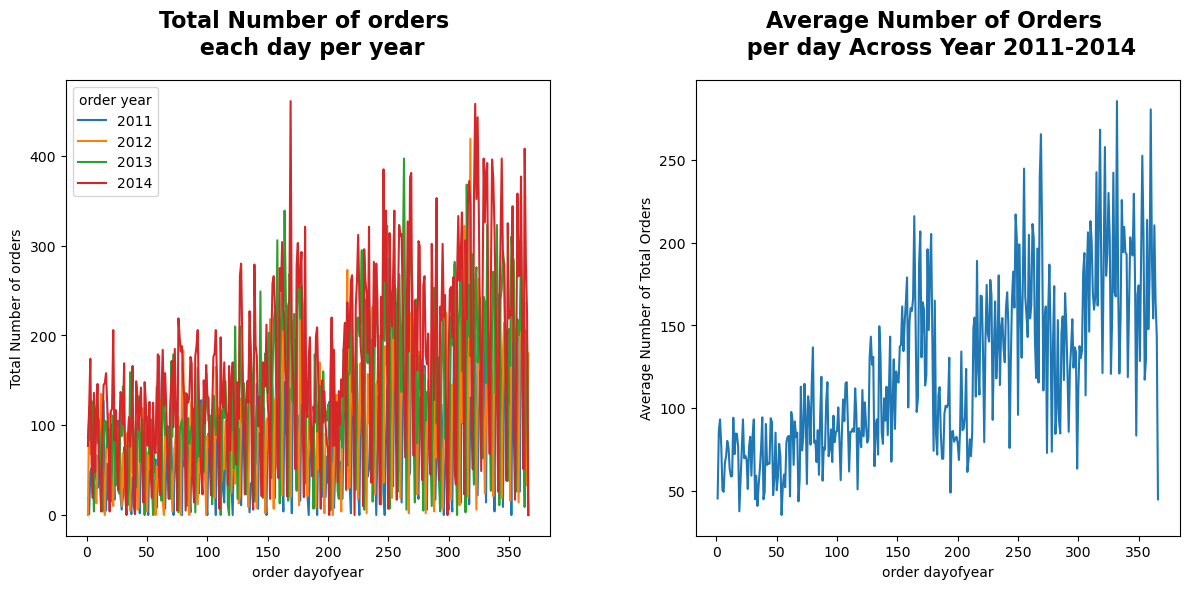

In [27]:
# seasonal trend of inventory by day of year.
day_df = order_df.groupby(['order year', 'order dayofyear'])['quantity'].sum().unstack('order year').fillna(0)

# mean of a product for each day across all years
day_df['mean'] = day_df.mean(axis=1)

# look at day_df data
display(day_df.head())

# plot the total and average number of orders each day across years
fig, ax = plt.subplots(1,2, figsize=(12,6))
day_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Number of orders \n each day per year', fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel('Total Number of orders')

day_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Number of Orders \n per day Across Year 2011-2014', fontsize=16, fontweight='bold',y=1.04)
ax[1].set_ylabel('Average Number of Total Orders')

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**The daily chart seems to show some seasonality trends but its bit noisy due to high frequency. Moreover, daily frequency seems too granular for inventory management. Let's reproduce the above result for lower temporal frequency(like, week, month).**

order year,2011,2012,2013,2014,mean
order week,,,,,
1,291,630,854,1361,784.00
2,385,451,553,556,486.25
3,325,414,517,755,502.75
4,367,430,439,730,491.50
5,287,306,593,658,461.00


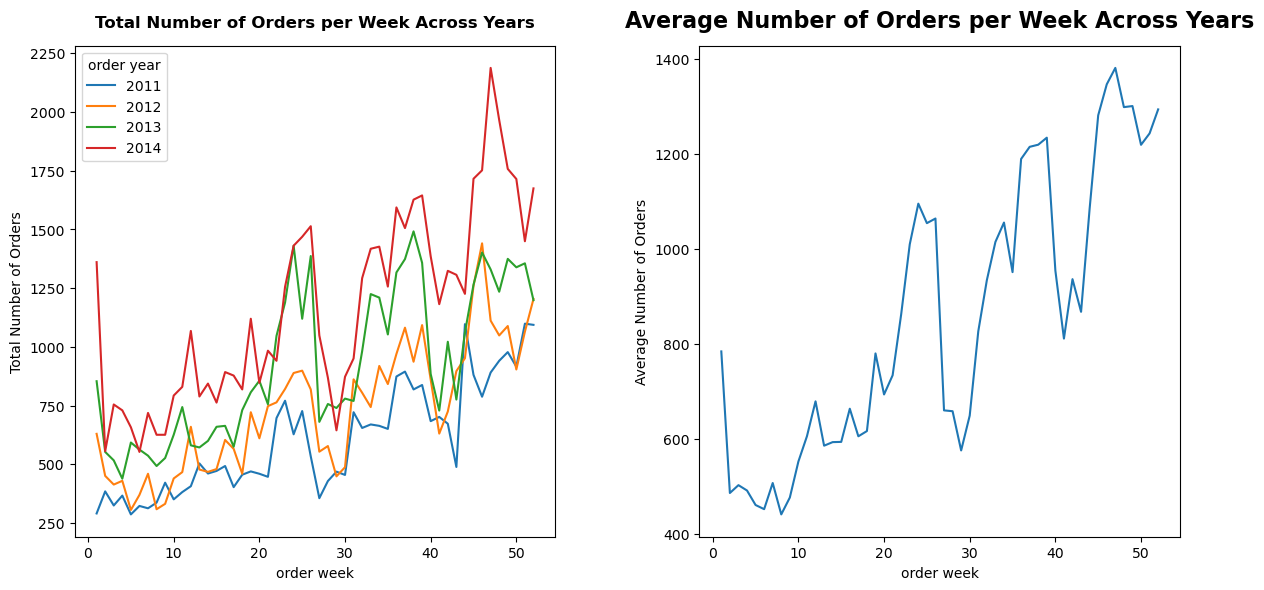

In [28]:
week_df = order_df.groupby(['order year', 'order week'])['quantity'].sum().unstack('order year').fillna(0)

# mean of a product for each week across years
week_df['mean'] = week_df.mean(axis=1)

# look at the data
display(week_df.head())
# plot the total quantity of each week across years and aveage quantity of each week across years as well
fig, ax = plt.subplots(1,2, figsize=(12,6))
week_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Number of Orders per Week Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Number of Orders')

week_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Number of Orders per Week Across Years', fontsize=16, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Number of Orders')

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


**The week analysis shows some seasonality trends and it looks more clearer and relevant than the daily analysis. The trend is generally consistent across the years. Mean of total orders seems like a good summary.**

order year,2011,2012,2013,2014,mean
order month,,,,,
1,1463,1845,2413,3122,2210.75
2,1224,1473,2102,2482,1820.25
3,1836,2237,2686,3722,2620.25
4,2020,2250,2688,3594,2638.00
5,2013,2921,3808,4300,3260.50


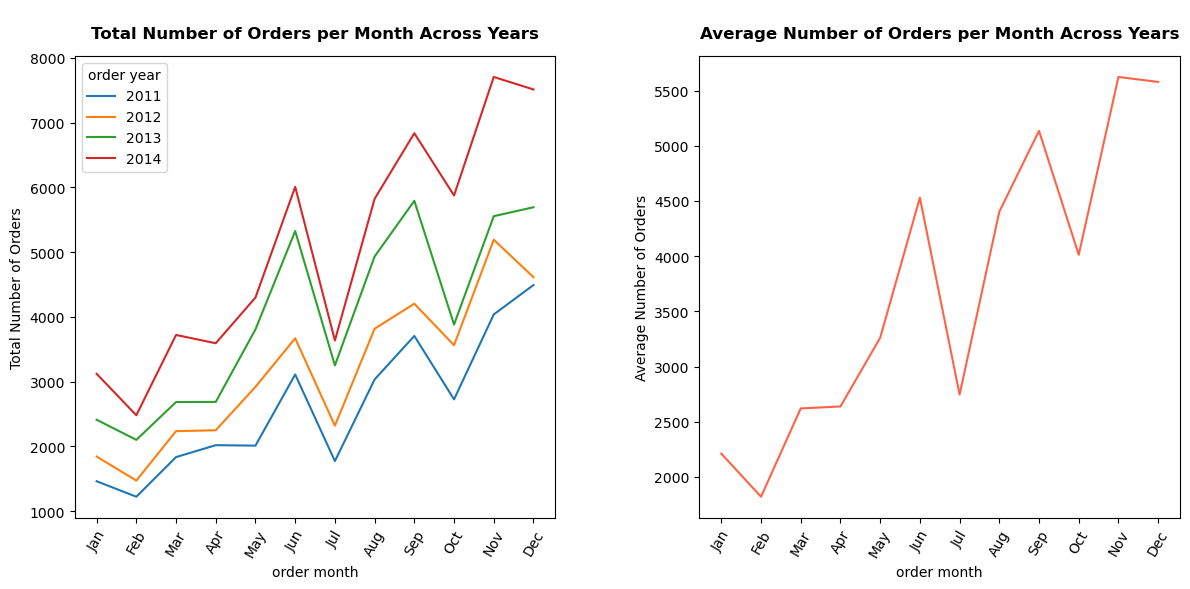

In [29]:
month_df = order_df.groupby(['order year', 'order month'])['quantity'].sum().unstack('order year').fillna(0)

# mean of a product for each week across years
month_df['mean'] = month_df.mean(axis=1)

# look at the data
display(month_df.head())
# plot the total quantity of each month across years and aveage quantity of each month across years as well
fig, ax = plt.subplots(1, 2, figsize=(12,6))
month_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Number of Orders per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Number of Orders')
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

month_df.iloc[:,-1].plot(ax=ax[1], color='tomato')
ax[1].set_title('\nAverage Number of Orders per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Number of Orders')
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add label and layouts
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


**Although daily, weekly and monthly analysis are consistent in showing seasonality trends however, weekly and monthly analysis are better for seasonality analysis for inventory management.**

This reveals both **trend growth** and **recurring seasonal spikes** more clearly.

**Insight Observations of Monthly Seasonality:**

| **Aspect** | **Findings** |
|-------|-----|
| **Seasonality** | Strong annual seasonality with Nov-Dec peaks. |
| **Trend** | Gradual upward trend across years. |
| **Post-holiday slump** | Sharp dip in Jan-Feb across all years. | 
| **Yearly Consistency** | Each year follows a similar monthly pattern. |
| **Year-over-Year Growth** | Later years(e.g., 2014) have higher total quantities than earlier years. |
| **Key Months** | Low: Jan-Feb; High: Nov-Dec. |
| **Slight Mid-year dip** | Some years show reduced quantity in Aug-Sep due to fewer corporate orders. |


**Summary of Yearly Seasonal Peaks:**

| **Year** | **General Monthly Quantity Pattern** |
|--------- | ------------------------------------ |
| **2011** | Low overall quantities (business ramp-up) |
| **2012** | Increase in total quantities; clear peak in Q4 |
| **2013** | Strong seasonality -- spikes in November, December |
| **2014** | Highest overall quantities; peaks even sharper in Q4 |

**To examine whether seasonal trend same for different categories, knowing average of trends across the given years is a good summary. We can calculate for each category, the average of total order for each month across given years.**

category     Furniture  Office Supplies  Technology
order month                                        
1               436.50          1368.00      406.25
2               362.50          1060.75      397.00
3               534.00          1581.50      504.75
4               504.75          1612.25      521.00
5               617.00          2017.75      625.75
6               864.50          2765.25      900.00
7               541.25          1641.50      563.25
8               769.00          2752.75      881.00
9              1029.25          3155.25      951.00
10              824.50          2350.75      837.00
11             1111.50          3410.75     1101.25
12             1143.75          3329.00     1105.75



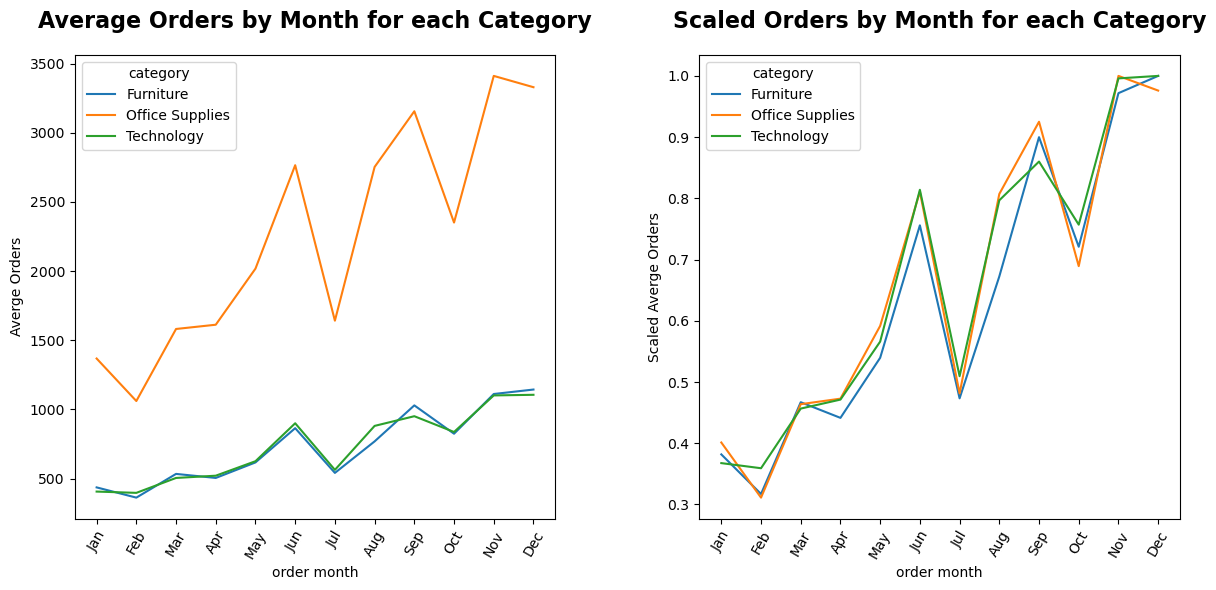

In [30]:
category_df = order_df.groupby(['order month', 'order year', 'category'])['quantity'].sum().unstack('order year').mean(axis=1).unstack('category')
print(category_df, end='\n\n')

# Lets normalize by max of order so we can compare seasonality across the product
scaled_df = category_df.apply(lambda col: col/col.max())

# visualize the average order by month for each category and scaled average order by month for each category
fig, ax = plt.subplots(1, 2, figsize=(12,6))
category_df.plot(ax=ax[0])
ax[0].set_title("Average Orders by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel("Averge Orders")
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

scaled_df.plot(ax=ax[1])
ax[1].set_title("Scaled Orders by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[1].set_ylabel("Scaled Averge Orders")
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


**Insights from Category Seasonal Trends:**

| **Category** | **Seasonal Trend** | **Description** |
| ------------ | ------------------ | --------------- |
| **Office Supplies** | Strong peaks in Nov-Dec and peaks in Q2 and Q3, aligning with school-reopen and school-Mid-term-examination. | High-volume, consistant sales throughout the year, with spikes near-end. |
| **Technology**      | Moderate peaks in Q4.    | Seasonal sales spikes in Q4 due to holiday shopping.|
| **Furniture**       | Mild Q4 bump; slight dips in mid-year(jun-july)            | Fewer orders, less pronounced seasonality. |

### **Recommendations:**

**1. Demand Forecasting & Inventory Planning:**
- Increase inventory and staffing in Q4 to meet demand.
- Reduce overstocking in Q1-Q2, whend demand drops.

**2. Category-Specific Inventory Planning:**
- **Office Supplies:** Target student and educators in Q2 and Q3; offer discount in Jan-Feb for business planning cycles.
- **Furniture:** Maintain steady stock year-round; optimize warehouse space and use predictive restocking.
- **Technology:** Run pre-holiday marketing and ensure tech stock availability.


The central question is why did the customers return the order, how frequently and the revenue lost due to returns.

1. How much profit did we lose due to returns each year?

2. How many customer returned more than once? more than 5 times?

3. Which regions are more likely to return orders?

4. Which categories (sub-categories) of products are more likely to be returned?


## **Profit Analysis**

**2. What do you have?**

To Perform profit analysis, the dataset should include at least:

**Key Metrics**: Profit and its derive metrics.

**Dimensions**: slice key metrics with columns such as year, category, region to see increase or decrease; highest or lowest etc. impact on profit.

**Team**: insights and recommendations belongs to which team such as marketing, product,etc.

In [31]:
# merge orders and returns dfs using 'order id' and 'market' which are common columns in both dfs, 
# so we can use only two columns of returns df, 
# use left-join so we can have all orders data with profit and whether they are returned or not.

# NOTE: An 'order id' is not unique, with the same 'order id(at purchase), 
# you can buy multiple items at multiple time and every time new 'order id' will generate, 
# when dfs will be merged, will see number of returns produc greater than shape of returns df
orders_merged = pd.merge(order_df, returns, on=['order id', 'market'], how='left')

# Look into dataset(orders_merged)
orders_merged.head(2)

,row id,order id,order date,ship date,ship mode,customer id,customer name,segment,city,state,country,postal code,market,region,product id,category,sub-category,product name,sales,quantity,discount,profit,shipping cost,order priority,order year,order month,order week,order dayofyear,order yearmonth,returned
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,2012,7,31,213,2012-07,NaN
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2013,2,6,36,2013-02,True


,total_profit,profit_lost(due to returns),profit_lost(%),actual_profit,actual_profit(%)
order year,,,,,
2011,248940.81154,16681.23932,6.700886,232259.57222,93.299114
2012,307415.27910,29338.40460,9.543574,278076.87450,90.456426
2013,406935.23018,22666.00628,5.569930,384269.22390,94.430070
2014,504165.97046,49482.04278,9.814634,454683.92768,90.185366


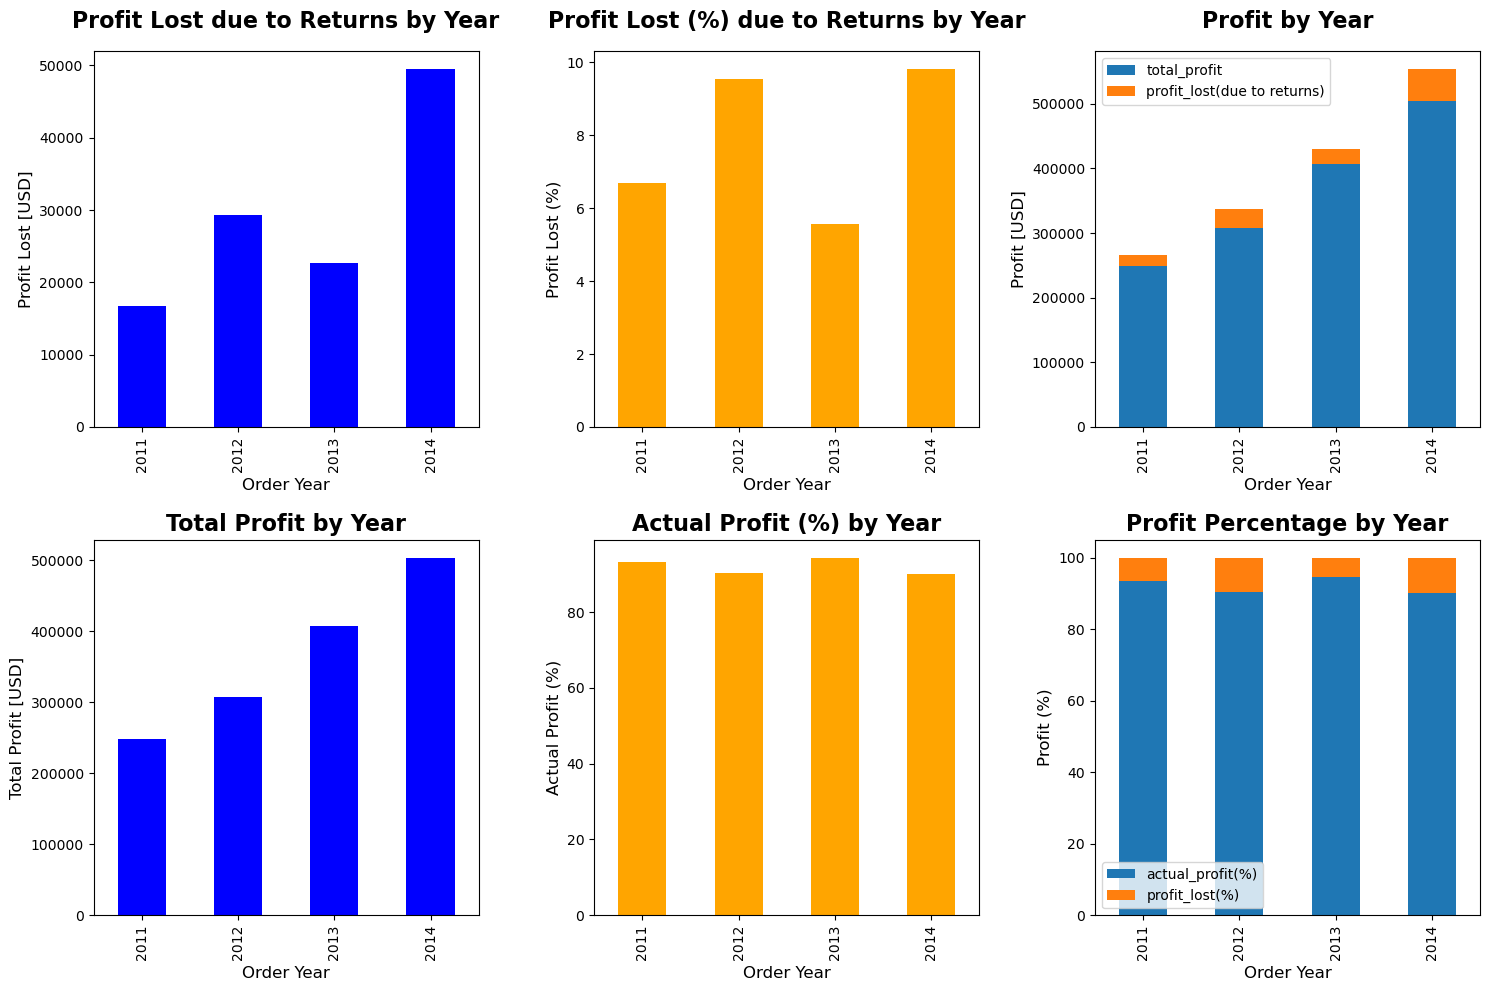

In [32]:
# Total profit by year
profit_df = orders_merged[['order year', 'profit']].groupby(['order year']).agg(total_profit = ('profit', 'sum'))
# Profit lost due to returns
order_returned = orders_merged[orders_merged['returned'] == True]
profit_df['profit_lost(due to returns)'] = order_returned[['order year', 'profit']].groupby(['order year']).agg(profit_lost = ('profit', 'sum'))
profit_df['profit_lost(%)'] = (profit_df['profit_lost(due to returns)'] / profit_df['total_profit']) * 100
profit_df['actual_profit'] = profit_df['total_profit'] - profit_df['profit_lost(due to returns)']
profit_df['actual_profit(%)'] = 100 - profit_df['profit_lost(%)']
display(profit_df)

# visualize profit data
fig, ax = plt.subplots(2,3, figsize=(15,10))
# 1. profit lost due to returns by year
profit_df['profit_lost(due to returns)'].plot(ax=ax[0, 0], kind='bar', color='blue')
ax[0, 0].set_title('Profit Lost due to Returns by Year', fontsize=16, fontweight='bold', y=1.04)
ax[0, 0].set_ylabel('Profit Lost [USD]', fontsize=12)
ax[0, 0].set_xlabel('Order Year', fontsize=12)

# 2. profit lost percentage by year
profit_df['profit_lost(%)'].plot(ax=ax[0, 1], kind='bar', color='orange')
ax[0, 1].set_title('Profit Lost (%) due to Returns by Year', fontsize=16, fontweight='bold', y=1.04)
ax[0, 1].set_ylabel('Profit Lost (%)', fontsize=12)
ax[0, 1].set_xlabel('Order Year', fontsize=12)

# 3. profit by year
profit_df[['total_profit','profit_lost(due to returns)']].plot(ax=ax[0, 2], kind='bar',stacked=True)
ax[0, 2].set_title('Profit by Year', fontsize=16, fontweight='bold', y=1.04)
ax[0, 2].set_ylabel('Profit [USD]', fontsize=12)
ax[0, 2].set_xlabel('Order Year', fontsize=12)

# 4. Total profit by year
profit_df['total_profit'].plot(ax=ax[1, 0], kind='bar', color='blue')
ax[1, 0].set_title('Total Profit by Year', fontsize=16, fontweight='bold')
ax[1, 0].set_ylabel('Total Profit [USD]', fontsize=12)
ax[1, 0].set_xlabel('Order Year', fontsize=12)

# 5. actual profit percentage by year
profit_df['actual_profit(%)'].plot(ax=ax[1, 1], kind='bar', color='orange')
ax[1, 1].set_title('Actual Profit (%) by Year', fontsize=16, fontweight='bold')
ax[1, 1].set_ylabel('Actual Profit (%)', fontsize=12)
ax[1, 1].set_xlabel('Order Year', fontsize=12)

# 6. profit percentage by year
profit_df[['actual_profit(%)','profit_lost(%)']].plot(ax=ax[1, 2], kind='bar', stacked=True)
ax[1, 2].set_title('Profit Percentage by Year', fontsize=16, fontweight='bold')
ax[1, 2].set_ylabel('Profit (%)', fontsize=12)
ax[1, 2].set_xlabel('Order Year', fontsize=12)

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


### **Insights:**

**1. Steady Growth in Total Proft Over the Years**
- The total profit tends to **increase year over year**, indicating a positive business growth trend and expansion into new market.
- This growth could be attributed to factors such as increased sales volume, market expansion, or improved operational efficiency.

**2. Impact of Returns on Profitability**
- Returns have a noticeable impact on profitability, with a significant portion of profit being lost due to returned items.
- The **profit lost due to returns** ranges between 6-10% of total profit annually.
- This highlights the imporatnce of addressing return rates to improve overall profitability and it **reduces the net profitability**.

**3. Category Patterns**

**4. Region Differences**


### **Return Rate Analysis**

#### **what is the overall trend of return rate?**

Let's analyze how many customers are returned more more than once? more than 5 times?

- The interpretation of return may depends on how we would like to define 'return': a unique 'order id' could have multiple 'product id' (if multiple items were purchased in a single order/ day) and we could also have multiple quantaties of each product.

Want to count the **number of products** returned, we can analyze the data following way:

Number of returns by customers:
customer id
AA-10315     5
AA-10375     5
AA-10645     1
AB-10060     1
AB-10105    12
Name: returned, dtype: int64 

Number of customers by number of returns:
returned
1     101
2      86
3      79
4      72
5      66
6      51
7      34
8      33
9      26
10     21
11     18
12     10
13      7
14      6
15      1
16      2
17      1
18      2
19      1
20      1
31      1
Name: count, dtype: int64 



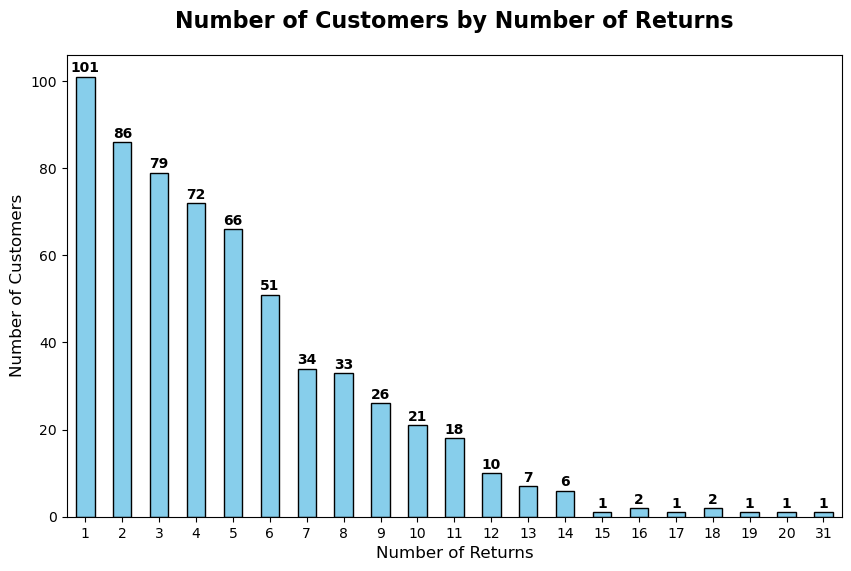

Number of customers with more than 1 returns: 518
Number of customers with more than 5 returns: 215


In [33]:
return_count_by_customer = order_returned.groupby('customer id')['returned'].count()

print("Number of returns by customers:")
print(return_count_by_customer.head(), '\n')

customers_count_by_return = return_count_by_customer.value_counts().sort_index()
print("Number of customers by number of returns:")
print(customers_count_by_return, '\n')

# visualize the number of customers by number of returns
customers_count_by_return.plot(kind='bar', figsize=(10,6), color='skyblue',edgecolor='black')
plt.title('Number of Customers by Number of Returns', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Number of Returns', fontsize=12)    
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(customers_count_by_return):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')
plt.show()

print(f"Number of customers with more than 1 returns: {sum( customers_count_by_return[customers_count_by_return.index > 1].values)}") 
print(f"Number of customers with more than 5 returns: {sum(customers_count_by_return[customers_count_by_return.index > 5].values)}")

Want to **count the number of unique orders returned**, can analyze the data following way:

Number of returns by customers:
customer id
AA-10315    2
AA-10375    2
AA-10645    1
AB-10060    1
AB-10105    5
Name: order id, dtype: int64 

Number of customers by number of returns:
order id
1    257
2    211
3     95
4     41
5     15
Name: count, dtype: int64 



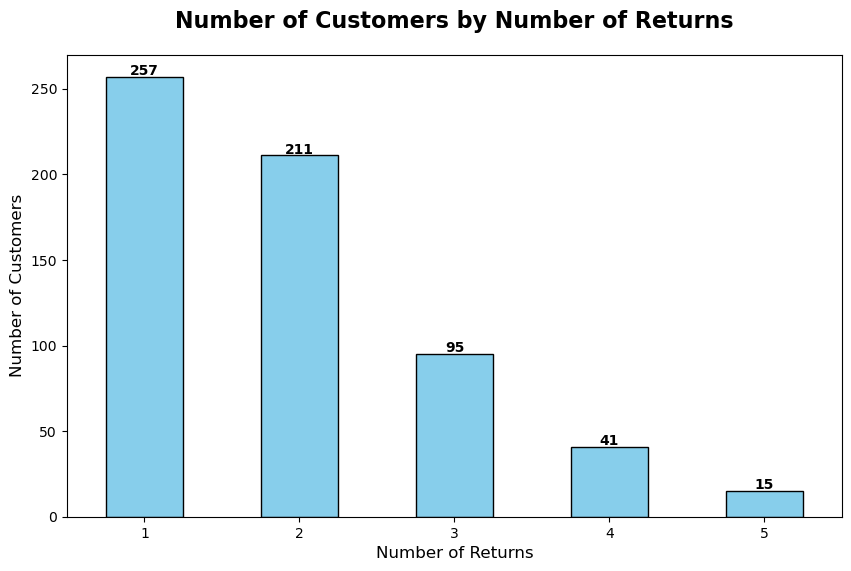

Number of customers with more than 1 returns: 362
Number of customers with more than 5 returns: 0


In [34]:
from graphql_relay import Edge


return_count_by_customer = order_returned.groupby('customer id')['order id'].nunique()

print("Number of returns by customers:")
print(return_count_by_customer.head(), '\n')

customers_count_by_return = return_count_by_customer.value_counts().sort_index()
print("Number of customers by number of returns:")
print(customers_count_by_return, '\n')

# visualize the number of customers by number of returns
customers_count_by_return.plot(kind='bar', figsize=(10,6), color='skyblue',edgecolor='black')
plt.title('Number of Customers by Number of Returns', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Number of Returns', fontsize=12)    
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(customers_count_by_return):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')
plt.show()

print(f"Number of customers with more than 1 returns: {sum( customers_count_by_return[customers_count_by_return.index > 1].values)}") 
print(f"Number of customers with more than 5 returns: {sum(customers_count_by_return[customers_count_by_return.index > 5].values)}")

**Return by Region**

In [35]:
# count order by Region
order_by_region = orders_merged.groupby('region')['order id'].nunique()
# count return by Region
return_by_region = orders_merged.query('returned == True').groupby('region')['order id'].nunique()
# puts this data into a dataframe
return_ratio_df = pd.DataFrame({
    'order_count': order_by_region,
    'return_count': return_by_region
})
return_ratio_df.fillna(0, inplace=True)
return_ratio_df['return_ratio'] = (return_ratio_df['return_count'] / return_ratio_df['order_count']) 
return_ratio_df.sort_values(by='return_ratio', ascending=False)

,order_count,return_count,return_ratio
region,,,
North Asia,1150,159.0,0.138261
West,1611,189.0,0.117318
North,2356,236.0,0.100170
Central,5249,251.0,0.047819
South,3270,134.0,0.040979
Southeast Asia,1517,55.0,0.036256
Oceania,1744,58.0,0.033257
East,1401,44.0,0.031406
Caribbean,855,25.0,0.029240


**Return by category**

,order_count,return_count,return_rate
category,,,
Furniture,9876,637,0.064500
Technology,10141,623,0.061434
Office Supplies,31273,1783,0.057014


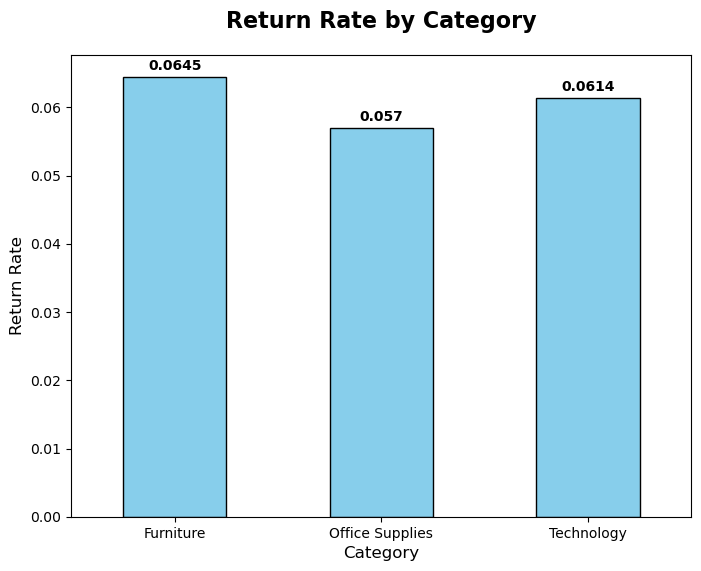

In [36]:
# count order by Region
order_by_category = orders_merged.groupby('category')['order id'].count()
# count return by Region
return_by_category = orders_merged.query('returned == True').groupby('category')['order id'].count()
# calculate return rate by category
return_rate = (return_by_category / order_by_category)
# puts this data into a dataframe
return_df = pd.DataFrame({
    'order_count': order_by_category,
    'return_count': return_by_category,
    'return_rate': return_rate
})

display(return_df.sort_values(by='return_rate', ascending=False))

# visualize the return rate by region
return_df['return_rate'].plot(kind='bar', figsize=(8,6), color='skyblue', edgecolor='black')
plt.title('Return Rate by Category', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Category', fontsize=12)    
plt.ylabel('Return Rate', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(return_df['return_rate'].round(4)):
    plt.text(i, v + 0.001, str(v), ha='center', fontsize=10, fontweight='bold')
plt.show()

**Return by Sub-Category**

In [37]:
# count order by sub-category
order_by_category = orders_merged.groupby(['category', 'sub-category'])['order id'].count()
# count return by Region
return_by_category = orders_merged.query('returned == True').groupby(['category', 'sub-category'])['order id'].count()
# puts this data into a dataframe
return_df = pd.DataFrame({
    'order_count': order_by_category,
    'return_count': return_by_category
})

return_df['return_rate'] = (return_df['return_count'] / return_df['order_count']).round(4) 
print(return_df.sort_values(by='return_rate', ascending=False), '\n')


                              order_count  return_count  return_rate
category        sub-category                                        
Furniture       Tables                861            67       0.0778
Office Supplies Fasteners            2420           177       0.0731
Technology      Accessories          3075           218       0.0709
Office Supplies Appliances           1755           124       0.0707
                Paper                3538           240       0.0678
Furniture       Chairs               3434           223       0.0649
                Furnishings          3170           201       0.0634
Technology      Copiers              2223           135       0.0607
Furniture       Bookcases            2411           146       0.0606
Office Supplies Envelopes            2435           146       0.0600
Technology      Phones               3357           198       0.0590
Office Supplies Supplies             2425           142       0.0586
                Labels            

### **Return Product Analysis**

In [38]:
print("Data type of 'returned' column ->", orders_merged['returned'].dtype, end='\n\n')
print("Value Counts of 'returned' columns",'\n',orders_merged['returned'].value_counts(dropna=False))

Data type of 'returned' column -> object

Value Counts of 'returned' columns 
 returned
NaN     48247
True     3043
Name: count, dtype: int64


**Clean the 'returned' columns**

In [39]:
orders_merged['returned_new'] = orders_merged['returned'].map(lambda x: 1 if x is True else 0)
# let's check the transforamtion
print("Value Counts of 'returned_new' column post transforamtion",'\n' ,orders_merged['returned_new'].value_counts(dropna=False))

Value Counts of 'returned_new' column post transforamtion 
 returned_new
0    48247
1     3043
Name: count, dtype: int64


In [40]:
orders_merged['returned_new'].unique()

array([0, 1], dtype=int64)

**NOTE** : The **Returned** information is based on **Product ID**. This means when order is returned, we analyze the return at the product level rather than order level. Each row is unique based on the combination of **'customer id' 'order id' and 'product id'**.

In [41]:
orders_merged[['customer id', 'order id', 'product id', 'quantity', 'returned_new']].sort_values(by=['order id']).head()

,customer id,order id,product id,quantity,returned_new
34136,PO-8865,AE-2011-9160,TEC-EPS-10004171,6,0
29578,PO-8865,AE-2011-9160,OFF-FEL-10001405,2,0
5597,EB-4110,AE-2013-1130,FUR-BUS-10003055,6,0
51156,EB-4110,AE-2013-1130,OFF-ACC-10004278,1,0
42362,MY-7380,AE-2013-1530,OFF-TEN-10002817,1,0


### **How Process time affects return of a product/order ?**

Let's introduce a new column **'process time'** which calculates the number of days taken to process an order from order date to ship date. The idea is how long it takes to ship and how it affect whether a product will be returned or not and the rate of returned based on **process time** is presented below.

In [42]:
# create process time column
orders_merged['process time'] = (orders_merged['ship date'] - orders_merged['order date']).dt.days
# look at the data
orders_merged[['order id', 'product id', 'order date', 'ship date', 'process time', 'returned_new']].head()
# create process time bin column
orders_merged['process time bin'] = pd.cut(orders_merged['process time'], bins=[0, 2, 5, 10, 999], labels=['0-2','3-5','6-10', '10+'])

correlation between process time and returned_new:
Pearson correlation coefficient: -0.0085, p-value: 0.0547 (not significant)


posx and posy should be finite values
posx and posy should be finite values


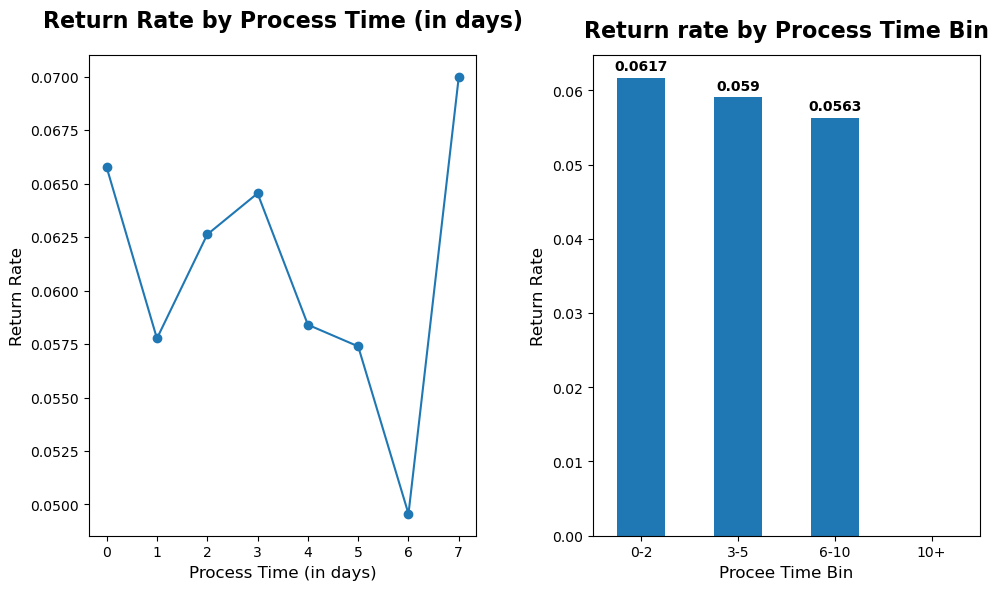

In [43]:
# compute return rate by process time and process time bin
return_rate_by_time = orders_merged.groupby(['process time'])['returned_new'].mean()
return_rate_by_bin = orders_merged.groupby('process time bin')['returned_new'].mean()

# statistical test to check if return rate by process time is significant
print("correlation between process time and returned_new:")
corr, p_value = stats.pearsonr(orders_merged['process time'], orders_merged['returned_new'])
significance = "significant" if p_value < 0.05 else "not significant"
print(f"Pearson correlation coefficient: {corr:.4f}, p-value: {p_value:.4f} ({significance})")
# visualize the trend
fig, ax = plt.subplots(1,2, figsize=(10,6))
return_rate_by_time.plot(ax=ax[0],rot=0,marker='o')
ax[0].set_title('Return Rate by Process Time (in days)', fontsize=16, fontweight='bold', y=1.04)
ax[0].set_xlabel('Process Time (in days)', fontsize=12)
ax[0].set_ylabel('Return Rate', fontsize=12)

return_rate_by_bin.plot(kind='bar',ax=ax[1],rot=0)
ax[1].set_title('Return rate by Process Time Bin', fontsize=16, fontweight='bold', y=1.02)
ax[1].set_xlabel('Procee Time Bin', fontsize=12)
ax[1].set_ylabel('Return Rate', fontsize=12)
for i, v in enumerate(return_rate_by_bin.round(4)):
    ax[1].text(i, v + 0.001, str(v), ha='center', fontsize=10, fontweight='bold')

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


**Category-level analysis**

           category process time bin  return_rate
0         Furniture              0-2     6.918983
1         Furniture              3-5     6.596396
2         Furniture             6-10     5.583195
3         Furniture              10+     0.000000
4   Office Supplies              0-2     6.179882
5   Office Supplies              3-5     5.533006
6   Office Supplies             6-10     5.498766
7   Office Supplies              10+     0.000000
8        Technology              0-2     5.408516
9        Technology              3-5     6.377383
10       Technology             6-10     6.068890
11       Technology              10+     0.000000


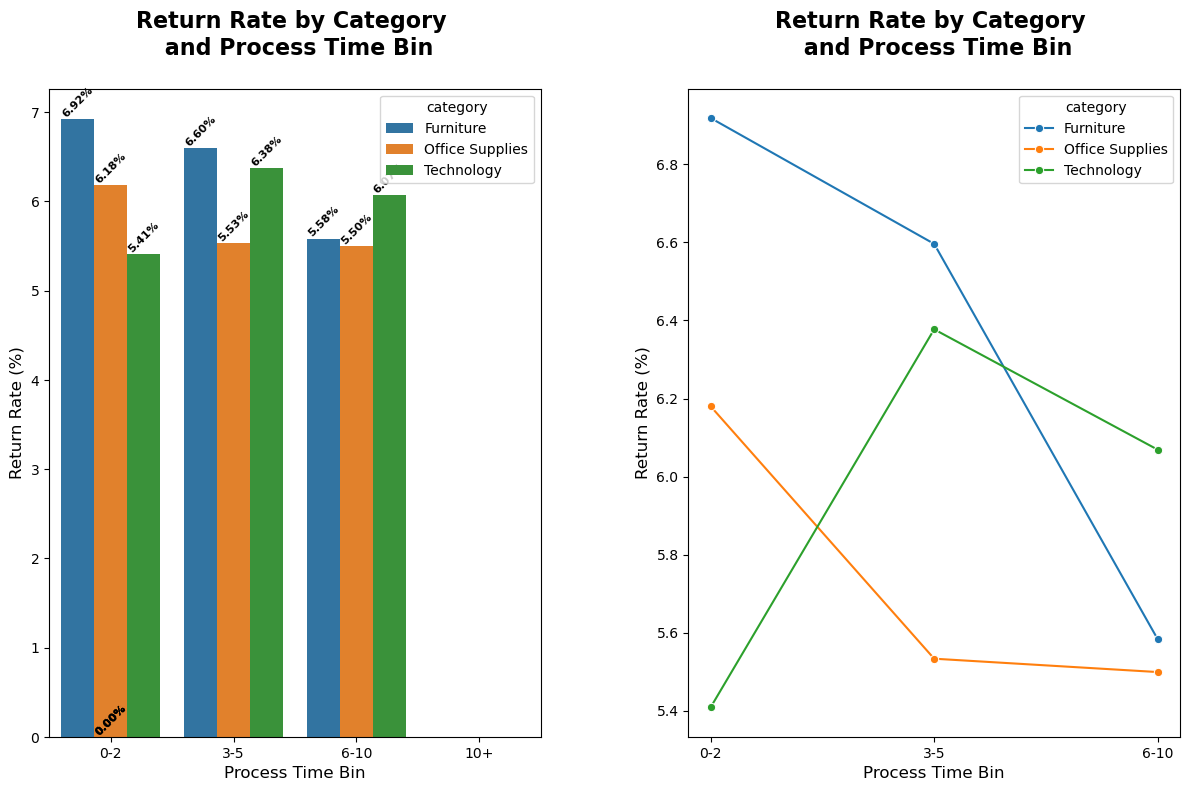

In [44]:

category_return = (
    orders_merged.groupby(['category', 'process time bin'])['returned_new']
    .apply(lambda x: (x == 1).mean()*100)
    .fillna(0)
    .reset_index(name ='return_rate')
)
print(category_return)
# visualize return rate by category and process time bin
fig, ax = plt.subplots(1, 2, figsize=(12,8))
category_return_new = category_return[~(category_return['process time bin'] == '10+')]
sns.barplot(data=category_return_new,x = 'process time bin', y = 'return_rate', hue = 'category', ax=ax[0])
ax[0].set_title('Return Rate by Category \n and Process Time Bin', fontsize=16, fontweight='bold', y=1.04)
ax[0].set_xlabel('Process Time Bin', fontsize=12)
ax[0].set_ylabel('Return Rate (%)', fontsize=12)
for p in ax[0].patches:
    height = p.get_height()
    ax[0].text(p.get_x() + p.get_width() / 2, height , f'{height:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)

sns.lineplot(data=category_return_new,x = 'process time bin', y = 'return_rate', hue='category',ax=ax[1], marker='o')
ax[1].set_title('Return Rate by Category \n and Process Time Bin', fontsize=16, fontweight='bold', y=1.04)
ax[1].set_xlabel('Process Time Bin', fontsize=12)
ax[1].set_ylabel('Return Rate (%)', fontsize=12)

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()